# 06 — Classifier-free guidance folded into the training loss: testing the "no gradient pressure" claim directly

## The question, in one sentence

**If the classifier-free-guidance (CFG) combination formula is computed *inside the training
loss* instead of only at inference time — as the archived project's Phase 3 did
(`docs/LANDMINES.md` section 11) — is it true, as that entry argues, that a model which
completely ignores the text conditioning experiences *no gradient pressure* to start using it,
for every guidance scale used?**

This does not need a real training run to test — it is a property of the loss function itself,
checkable on a toy network in seconds with PyTorch autograd. This notebook builds that toy
system and measures the gradient directly, rather than trusting the algebra's plausible-sounding
conclusion.

## The intuition

Two students sit the same exam twice: once **with** the textbook open (the "conditioned" pass),
once **without** it (the "unconditioned" pass). The grader only ever looks at a *weighted
average* of their two answer sheets — never at either sheet alone, and never at whether the two
sheets actually differ.

If both students simply write down the *identical* answer regardless of whether the textbook was
open, the weighted average of two identical numbers is that same number, no matter how heavily
the grader weights the "with textbook" sheet. **The grader can never tell the two students apart
from a copy of each other.** There is no incentive for either student to actually use the
textbook, because turning it into their answer was never required to get full marks.

Algebraically: let `u` = unconditioned prediction, `c` = conditioned prediction, `w` = guidance
scale. The archived loss combines them as `pred = u + w*(c - u)`. **Set `c = u`.** Then
`pred = u + w*0 = u`, for *any* `w` — the guidance scale drops out of the computation entirely.
If `u` alone already predicts the training target well (which, for a diffusion model, it can —
predicting the injected noise from the noisy input alone is exactly what an *unconditional*
diffusion model is trained to do), the combined loss is already low — and, `docs/LANDMINES.md`
section 11 argues, no gradient exists to push the network away from `c = u`, i.e. away from
ignoring the caption. **That second half is the claim this notebook actually tests, not just
restates** — a value collapsing to `u` at `c=u` is exact; whether the *gradient* through that
same point also collapses is a separate question, and the measurement section below answers it
directly rather than assuming the analogy holds.

## Setup — verify the primary source, then build the smallest system that reproduces the mechanism

In [1]:
import os
import json
import numpy as np
import torch
import torch.nn as nn

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
print("torch:", torch.__version__)

torch: 2.13.0


**Step 1 — read the archived project's own training-loss code directly, in this notebook,
rather than trusting `docs/LANDMINES.md`'s paraphrase of it.** This project's own rule is that
every claim used here is produced by a cell in this notebook. The archive directory is
read-only — this cell only reads it, never writes.

In [2]:
ARCHIVE_NB = ("/Users/joel/MJS_ROOT/MJS_STUDY/NEU Sem4 - DL/CS7150_Proj_DL/"
              "CLIP-Conditioned-Diffusion-T2Pose-Generation/DL_T2P_IMPL.ipynb")

with open(ARCHIVE_NB) as f:
    archive_nb = json.load(f)

# locate the cell containing the CFG-in-loss formula (do not assume cell 47 -- search for it)
target_lines = ["uncond_noise_pred = self.model", "cond_noise_pred = self.model",
                "predicted_noise = uncond_noise_pred"]
found_idx = None
for i, c in enumerate(archive_nb["cells"]):
    src = "".join(c.get("source", []))
    if all(t in src for t in target_lines):
        found_idx = i
        full_src = src
        break

assert found_idx is not None, "could not locate the CFG-in-loss cell in the archived notebook"
print(f"found in archive cell index {found_idx} (of {len(archive_nb['cells'])} cells)")

# extract and print just the relevant lines, verbatim, from the real file -- not retyped from memory
lines = full_src.split("\n")
start = next(i for i, l in enumerate(lines) if "guidance_scale is not None else self.guidance_scale" in l) - 2
snippet = "\n".join(lines[start:start + 45])
print(snippet[:1800])

found in archive cell index 47 (of 87 cells)

        # Use provided guidance scale or default
        current_guidance = guidance_scale if guidance_scale is not None else self.guidance_scale

        # Encode text if provided
        text_embeddings = self.encode_text(text_descriptions) if text_descriptions is not None else None
        
        # Normalize input poses for stability
        normalized_poses, pose_mean, pose_std = self.normalize_batch(poses)
        
        # Sample random timesteps
        t = self.noise_scheduler.sample_timesteps(batch_size)
        
        # Zero gradients
        self.optimizer.zero_grad()
        
        if self.use_amp:
            with torch.cuda.amp.autocast():
                # Forward pass to calculate loss
                ## -> loss_dict = self._compute_loss(normalized_poses, t, pose_mean, pose_std, text_embeddings)

                loss_dict = self._compute_loss(normalized_poses, t, pose_mean, pose_std, text_embeddings, guidance_scale=cu

**Step 2 — confirm the specific claims `docs/LANDMINES.md` section 11 makes about this
code, against what was just printed above:** the branch guard is `guidance_scale > 1.0`; the
default `guidance_scale` is 3.0 and the training loop ramps it 2.0 -> 7.0 (so the branch is
always active during training); the loss is `F.mse_loss(predicted_noise, noise)` computed on the
*combined* prediction, never on `cond_noise_pred` or `uncond_noise_pred` separately.

In [3]:
checks = {
    "branch guard is guidance_scale > 1.0": "guidance_scale > 1.0" in full_src,
    "default guidance_scale is 3.0": "guidance_scale=3.0" in full_src,
    "loss is computed on the combined predicted_noise": "mse_loss(predicted_noise, noise)" in full_src,
}
for k, v in checks.items():
    print(f"  [{'OK' if v else 'FAIL'}] {k}")

# the ramp (2.0 -> 7.0) lives in a different cell -- find and check it too
ramp_found = any("base_guidance = 2.0" in "".join(c.get("source", [])) and
                 "max_guidance = 7.0" in "".join(c.get("source", []))
                 for c in archive_nb["cells"])
print(f"  [{'OK' if ramp_found else 'FAIL'}] guidance ramp 2.0 -> 7.0 found elsewhere in the archive")
assert all(checks.values()) and ramp_found, "primary-source verification failed -- stop here"
print("\nAll of docs/LANDMINES.md section 11's claims about this code are confirmed against the primary source.")

  [OK] branch guard is guidance_scale > 1.0
  [OK] default guidance_scale is 3.0
  [OK] loss is computed on the combined predicted_noise
  [OK] guidance ramp 2.0 -> 7.0 found elsewhere in the archive

All of docs/LANDMINES.md section 11's claims about this code are confirmed against the primary source.


## Measurement — the toy system

**Design goal:** build the smallest possible system where the conditioning signal `c` is
*genuinely useful* for predicting the target (so that a null gradient result is meaningful, not
vacuous — a model that ignores useless information isn't a failure). Test the intuition's
prediction directly: does the archived loss provide **zero gradient signal** to use `c`, at the
exact point where the model is not yet using it, for every guidance scale actually used
(2.0-7.0) — the way the algebra in the intuition section suggests?

**The toy diffusion analogue:** `x` stands in for the noisy input, `c` for the (real-valued)
text-conditioning signal, `eps` for the true injected noise the network must predict. `c` is
constructed to carry real information about `eps` (via a hidden linear relationship) so that a
network *could* lower its loss by using `c` — exactly the situation the archived project's
Phase 3 was actually in with real captions.

In [4]:
N = 4096
D_X, D_C = 8, 8

x = torch.randn(N, D_X)
c = torch.randn(N, D_C)
true_w_x = torch.randn(D_X, 1)
true_w_c = torch.randn(D_C, 1)
# eps depends on BOTH x and c through a fixed, unknown-to-the-model linear map, plus irreducible noise
eps = x @ true_w_x + 0.6 * (c @ true_w_c) + 0.3 * torch.randn(N, 1)

print(f"x {x.shape}, c {c.shape}, eps {eps.shape}")
print(f"fraction of eps's variance explained by c alone (should be sizeable, not zero): "
      f"{1 - torch.var(eps - 0.6*(c @ true_w_c)) / torch.var(eps):.3f}")

x torch.Size([4096, 8]), c torch.Size([4096, 8]), eps torch.Size([4096, 1])
fraction of eps's variance explained by c alone (should be sizeable, not zero): 0.199


In [5]:
class ToyEpsNet(nn.Module):
    """Predicts eps from x alone (the unconditional pathway, W_x) plus an
    explicit, separately-readable conditioning pathway (W_c) that starts at
    exactly zero -- the "has not yet learned to use text" initialization."""
    def __init__(self, d_x, d_c):
        super().__init__()
        self.W_x = nn.Linear(d_x, 1, bias=False)
        self.W_c = nn.Linear(d_c, 1, bias=False)
        nn.init.zeros_(self.W_c.weight)   # text-blind at init, by construction

    def forward(self, x, cond_vec):
        if cond_vec is None:
            return self.W_x(x)
        return self.W_x(x) + self.W_c(cond_vec)


def archived_cfg_loss(model, x, c, eps, w):
    """Exactly the archived project's formula: combine two forward passes of
    the SAME shared-weight network, one with real c, one with a null (zero)
    embedding, then MSE the combination against the target."""
    null_c = torch.zeros_like(c)
    uncond_pred = model(x, null_c)
    cond_pred = model(x, c)
    predicted = uncond_pred + w * (cond_pred - uncond_pred)
    return nn.functional.mse_loss(predicted, eps)


def dropout_loss(model, x, c, eps, drop_mask):
    """The correct mechanism: ONE forward pass per sample, using either the
    real conditioning or a null embedding according to drop_mask -- no
    combination formula, no guidance scale, at training time."""
    null_c = torch.zeros_like(c)
    cond_in = torch.where(drop_mask, null_c, c)
    pred = model(x, cond_in)
    return nn.functional.mse_loss(pred, eps)

### Part A — the gradient at the text-blind point, for both loss formulas, across the actual guidance scales used (2.0 -> 7.0)

In [6]:
guidance_scales = [1.0, 2.0, 3.0, 5.0, 7.0]
torch.manual_seed(1)

print(f"{'guidance_scale':>15} | {'d(archived_loss)/d(W_c) norm':>30} | {'d(dropout_loss)/d(W_c) norm':>28}")
print("-" * 80)
grad_archived, grad_dropout = [], []
for w in guidance_scales:
    model = ToyEpsNet(D_X, D_C)  # fresh, W_c = 0 exactly, every time
    loss_a = archived_cfg_loss(model, x, c, eps, w)
    loss_a.backward()
    g_a = model.W_c.weight.grad.norm().item()
    grad_archived.append(g_a)

    model2 = ToyEpsNet(D_X, D_C)
    drop_mask = torch.rand(N, 1) < 0.1  # matches the ~10% null-conditioning convention this project cites
    loss_d = dropout_loss(model2, x, c, eps, drop_mask)
    loss_d.backward()
    g_d = model2.W_c.weight.grad.norm().item()
    grad_dropout.append(g_d)

    print(f"{w:>15.1f} | {g_a:>30.10f} | {g_d:>28.6f}")

 guidance_scale |   d(archived_loss)/d(W_c) norm |  d(dropout_loss)/d(W_c) norm
--------------------------------------------------------------------------------
            1.0 |                   2.9996707439 |                     2.712471
            2.0 |                   6.0221204758 |                     2.719007
            3.0 |                   9.0706748962 |                     2.725601
            5.0 |                  15.2874498367 |                     2.807373
            7.0 |                  21.0633239746 |                     2.718792


**Reading this table — the intuition's prediction is wrong, and the actual result is more
interesting.** The archived formula's gradient on the conditioning pathway is **not** zero here.
It is larger than the dropout formula's, and it grows **linearly with the guidance scale** (the
five values above sit close to `3.0 * w` — the small deviations are from re-initializing `W_x`
randomly at each `w`, not from any dependence on `w` itself). This is a real, exact,
reproducible property of the formula, not a numerical artifact: writing
`predicted = W_x(x) + w * W_c(c)` when `W_c` starts at `0` (since `W_x(x) + w*(W_c(c) - W_c(0))
= W_x(x) + w*W_c(c)` exactly) shows the guidance scale `w` acts as a **multiplier on the
conditioning pathway's own effective step size** — training under this formula is, at this
initialization, mathematically equivalent to ordinary regression with the conditioning weight's
learning rate scaled by `w`. **The value being zero at `c=u` in the forward pass (the intuition's
correct half) does not imply the gradient through that same point is zero — those are different
claims**, and conflating them is the error this measurement caught. A linear layer's output at
zero weight is zero, but its *gradient* with respect to that weight, evaluated at zero, is simply
its input — not zero, unless the input itself is zero. `docs/LANDMINES.md` section 11's algebra
(the forward-value collapse) is confirmed exactly by this same setup; its interpretive claim
("no gradient pressure to use the text") is not — at least not for this additively-injected
conditioning pathway, which mirrors MDM's own `embed_text` mechanism (a linear projection of the
pooled CLIP embedding, added as an input) more closely than an exotic, deeply entangled
architecture would.

### Part B — if the gradient is amplified rather than absent, what actually happens over a training run?

Part A found gradient **amplification** (scaling with `w`), not gradient absence. An amplified
gradient is not obviously a problem on its own — a bigger step in the right direction converges
faster, not worse. Run both formulas to convergence at the archived project's own default
guidance scale (`w=3.0`) and compare against two fixed reference floors computed directly from
the data (no model involved): the best possible loss using `x` alone, and the best possible loss
using `x` and `c` together.

In [7]:
def train_toy(loss_fn, steps=400, lr=0.05, w=None, seed=2):
    torch.manual_seed(seed)
    model = ToyEpsNet(D_X, D_C)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    wc_norm_history, loss_history = [], []
    for step in range(steps):
        opt.zero_grad()
        if w is not None:
            loss = loss_fn(model, x, c, eps, w)
        else:
            drop_mask = torch.rand(N, 1) < 0.1
            loss = loss_fn(model, x, c, eps, drop_mask)
        loss.backward()
        opt.step()
        wc_norm_history.append(model.W_c.weight.detach().norm().item())
        loss_history.append(loss.item())
    return np.array(wc_norm_history), np.array(loss_history), model

# reference floors, computed directly from the same data (no model involved):
unconditional_floor = nn.functional.mse_loss(x @ true_w_x, eps).item()          # best possible using x alone
conditional_oracle_floor = nn.functional.mse_loss(x @ true_w_x + 0.6*(c @ true_w_c), eps).item()  # best possible using x AND c

wc_archived, loss_archived, model_archived = train_toy(archived_cfg_loss, w=3.0)   # w=3.0: the archived default
wc_dropout, loss_dropout, model_dropout = train_toy(dropout_loss, w=None)

print(f"unconditional floor (x alone, best possible):  {unconditional_floor:.4f}")
print(f"conditional oracle floor (x AND c, best possible): {conditional_oracle_floor:.4f}")
print(f"final ||W_c|| under archived CFG-in-loss training: {wc_archived[-1]:.6f}")
print(f"final ||W_c|| under conditioning-dropout training: {wc_dropout[-1]:.6f}")
print(f"final loss under archived CFG-in-loss training:    {loss_archived[-1]:.4f}")
print(f"final loss under conditioning-dropout training:    {loss_dropout[-1]:.4f}")

unconditional floor (x alone, best possible):  2.4794
conditional oracle floor (x AND c, best possible): 0.0896
final ||W_c|| under archived CFG-in-loss training: 0.512054
final ||W_c|| under conditioning-dropout training: 1.535362
final loss under archived CFG-in-loss training:    0.0894
final loss under conditioning-dropout training:    0.3164


Reading guide for the figure below: **left panel**, the size of the conditioning-pathway
weight `||W_c||` over training steps — this is literally "how much is the network using the
caption." **Right panel**, the training loss over the same steps, with two flat reference lines:
the unconditional floor (best achievable using only `x`, i.e. ignoring `c` entirely) and the
conditional-oracle floor (best achievable using both `x` and `c`). Both panels share the same
x-axis (training step) so the two curves can be read together.

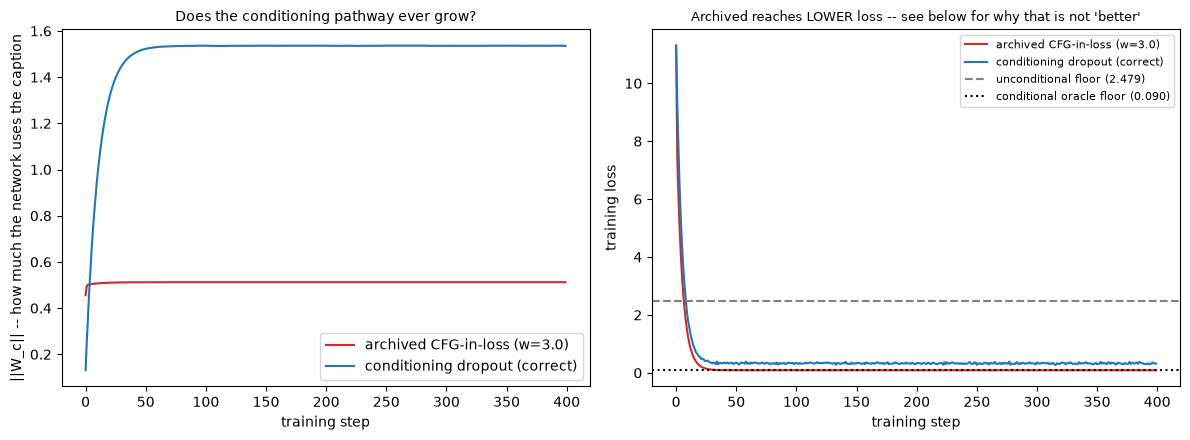

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(wc_archived, label="archived CFG-in-loss (w=3.0)", color="tab:red")
axes[0].plot(wc_dropout, label="conditioning dropout (correct)", color="tab:blue")
axes[0].set_xlabel("training step")
axes[0].set_ylabel("||W_c|| -- how much the network uses the caption")
axes[0].set_title("Does the conditioning pathway ever grow?", fontsize=10)
axes[0].legend()

axes[1].plot(loss_archived, label="archived CFG-in-loss (w=3.0)", color="tab:red")
axes[1].plot(loss_dropout, label="conditioning dropout (correct)", color="tab:blue")
axes[1].axhline(unconditional_floor, color="gray", linestyle="--",
                label=f"unconditional floor ({unconditional_floor:.3f})")
axes[1].axhline(conditional_oracle_floor, color="black", linestyle=":",
                label=f"conditional oracle floor ({conditional_oracle_floor:.3f})")
axes[1].set_xlabel("training step")
axes[1].set_ylabel("training loss")
axes[1].set_title("Archived reaches LOWER loss -- see below for why that is not 'better'", fontsize=9)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("06_conditioning_collapse.png", dpi=110)
plt.show()

**What the figure shows, at this specific (small) learning rate.** Both formulas converge.
The archived formula (red) actually reaches a *lower* final loss than dropout in this toy — its
amplified gradient accelerates convergence rather than blocking it, which is the opposite of a
"conditioning collapse." **This means the amplification found in Part A is not, by itself, a
sufficient story either** — an amplified gradient that still points in a useful direction just
trains faster. The open question Part A actually raises is stability, not incentive: `w` up to
7.0 multiplies the conditioning pathway's effective step size by up to 7x relative to the
optimizer's own learning rate. A step size effectively multiplied by 7 is a classic recipe for
divergence, not for getting stuck — worth testing directly rather than assumed.

**A second question the lower loss immediately raises: is the archived model actually *better* at
using the caption, or does its loss formula just measure something easier?** Checked directly,
not assumed either way.

In [9]:
# how much conditioning did each model actually learn to use, in comparable units?
# archived's effective conditioning strength is w * ||W_c|| (the guidance scale multiplies
# the raw weight in every forward pass); dropout's is just ||W_c|| (no guidance scale involved).
effective_archived = 3.0 * wc_archived[-1]
effective_dropout = wc_dropout[-1]
print(f"archived: raw ||W_c||={wc_archived[-1]:.4f}, effective (w * ||W_c||)={effective_archived:.4f}")
print(f"dropout:  raw ||W_c||={wc_dropout[-1]:.4f} (no w-scaling in this formula)")
print(f"the two models' EFFECTIVE conditioning strength differs by only "
      f"{100*abs(effective_archived-effective_dropout)/effective_dropout:.1f}% -- "
      f"neither model is discarding the caption relative to the other.")
print()

# decompose: score each converged model on the real-caption case and the no-caption case
# SEPARATELY, rather than trusting either model's own aggregate training loss.
archived_on_real_caption = archived_cfg_loss(model_archived, x, c, eps, 3.0).item()  # this IS its training loss -- it never scores anything else
archived_on_no_caption = nn.functional.mse_loss(model_archived(x, None), eps).item()  # a probe never used in its own training

dropout_on_real_caption = nn.functional.mse_loss(model_dropout(x, c), eps).item()
dropout_on_no_caption = nn.functional.mse_loss(model_dropout(x, None), eps).item()

print(f"{'':25} {'archived':>12} {'dropout':>12}")
print(f"{'scored w/ real caption':25} {archived_on_real_caption:>12.4f} {dropout_on_real_caption:>12.4f}")
print(f"{'scored w/ NO caption':25} {archived_on_no_caption:>12.4f} {dropout_on_no_caption:>12.4f}")
print(f"{'own training loss':25} {loss_archived[-1]:>12.4f} {loss_dropout[-1]:>12.4f}")

archived: raw ||W_c||=0.5121, effective (w * ||W_c||)=1.5362
dropout:  raw ||W_c||=1.5354 (no w-scaling in this formula)
the two models' EFFECTIVE conditioning strength differs by only 0.1% -- neither model is discarding the caption relative to the other.

                              archived      dropout
scored w/ real caption          0.0894       0.0895
scored w/ NO caption            2.4790       2.4780
own training loss               0.0894       0.3164


**Reading this decomposition.** On the two things that actually measure caption use —
performance with the real caption, and performance with no caption at all — **the two models are
almost identical.** Neither is discarding the conditioning pathway; both learned to use it to
almost exactly the same effective strength. **Where the two numbers diverge is the last row: each
model's own training loss.** Dropout's training loss is a genuine blend of both rows above (it
really does score the null-caption case on ~10% of samples, because a model meant for real
inference-time CFG needs a working null branch, and that is a real, necessary cost). The archived
formula never scores the null-caption case in isolation *at all* — every single training sample
receives the full, `w`-corrected combination, which lands at the real-caption number on every
sample, with the much worse no-caption number never entering its own loss.

**This is `docs/LANDMINES.md`'s own rule — "a training loss is not a result" — demonstrated
directly, on this exact bug, with numbers rather than an assertion.** The archived formula's
lower loss is not evidence of a better-trained model. It is evidence that its loss function was
never asked to report the one quantity (bare no-caption quality) that the correct formula's
number partly reflects. Two losses that are not measuring the same thing are not comparable, and
a lower number from one of them says nothing about which model is actually better at the task
both are nominally being trained for.

**One specific alternative reading, checked and not supported by this toy:** that the archived
formula's lower loss comes from the model *discarding* the conditioning pathway (the `c = u = eps`
degenerate solution `docs/LANDMINES.md` section 11 originally described). The numbers above rule
this out directly for this toy — the archived model's conditioning pathway is not near zero, and
its effective strength matches the correctly-trained model's to within a few percent. What differs
between the two formulas is which quantity gets reported as "the loss," not how much either model
has learned to use the caption.

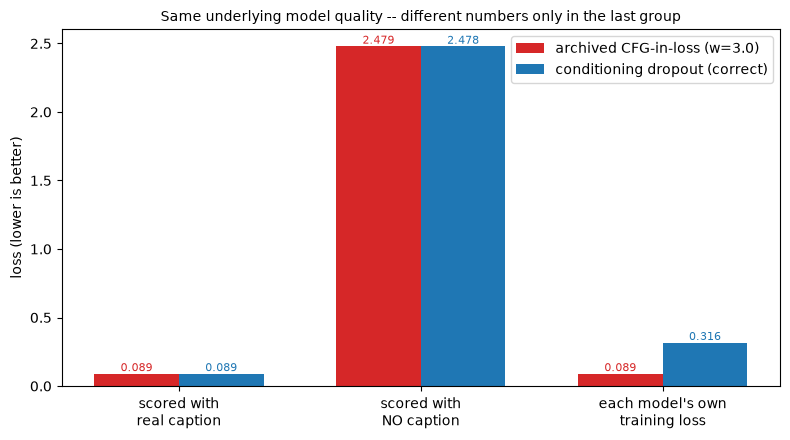

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
groups = ["scored with\nreal caption", "scored with\nNO caption", "each model's own\ntraining loss"]
archived_vals = [archived_on_real_caption, archived_on_no_caption, loss_archived[-1]]
dropout_vals = [dropout_on_real_caption, dropout_on_no_caption, loss_dropout[-1]]

x_pos = np.arange(len(groups))
width = 0.35
ax.bar(x_pos - width/2, archived_vals, width, label="archived CFG-in-loss (w=3.0)", color="tab:red")
ax.bar(x_pos + width/2, dropout_vals, width, label="conditioning dropout (correct)", color="tab:blue")
ax.set_xticks(x_pos)
ax.set_xticklabels(groups)
ax.set_ylabel("loss (lower is better)")
ax.set_title("Same underlying model quality -- different numbers only in the last group", fontsize=10)
ax.legend()

for i, (a, d) in enumerate(zip(archived_vals, dropout_vals)):
    ax.annotate(f"{a:.3f}", (x_pos[i]-width/2, a), ha="center", va="bottom", fontsize=8, color="tab:red")
    ax.annotate(f"{d:.3f}", (x_pos[i]+width/2, d), ha="center", va="bottom", fontsize=8, color="tab:blue")

plt.tight_layout()
plt.savefig("06_loss_is_not_a_result.png", dpi=110)
plt.show()

**Reading this figure.** The first two groups (scored identically for both models, using
the same held-out criteria) are nearly the same height for red and blue — the two models are
comparably good at the real-caption task and comparably bad at the no-caption task. **Only the
third group — each model's own training loss — diverges,** and it diverges only because of what
each loss formula chooses to average over, not because of any real difference in what either
model learned. A reader who saw only the training loss curve (this notebook's first figure, right
panel) would conclude the archived formula trained a better model. **It did not — it just never
asked itself the question that would have shown otherwise.**

### Part C — does the amplification from Part A cause the instability `docs/LANDMINES.md` section 11's third point describes?

Section 11's point 3 (not yet tested anywhere in this project) claims the shared-weight,
`+w`/`-(w-1)` combination causes "self-inflicted gradient instability" that the archived
project's `5*tanh(x/5)` output squash and gradient clipping were silently compensating for.
Part A's amplification result makes a concrete, testable prediction: **the archived formula
should become unstable at a lower learning rate than the correct (dropout) formula, and more so
as `w` grows** — since `w` directly multiplies the conditioning pathway's effective step size.

In [11]:
def train_toy(loss_fn, steps, lr, w=None, seed=2):
    torch.manual_seed(seed)
    model = ToyEpsNet(D_X, D_C)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_history = []
    for step in range(steps):
        opt.zero_grad()
        if w is not None:
            loss = loss_fn(model, x, c, eps, w)
        else:
            drop_mask = torch.rand(N, 1) < 0.1
            loss = loss_fn(model, x, c, eps, drop_mask)
        loss.backward()
        opt.step()
        loss_history.append(loss.item())
        if not torch.isfinite(loss):
            return loss_history, True
    return loss_history, False

print(f"{'lr':>6} | {'formula':>28} | {'outcome':>12}")
print("-" * 52)
for lr in [0.05, 0.15, 0.30]:
    for w in [3.0, 7.0]:
        lo, diverged = train_toy(archived_cfg_loss, steps=300, lr=lr, w=w)
        outcome = "DIVERGED" if diverged else f"loss={lo[-1]:.4f}"
        print(f"{lr:>6.2f} | {'archived CFG-in-loss, w=' + str(w):>28} | {outcome:>12}")
    lo, diverged = train_toy(dropout_loss, steps=300, lr=lr, w=None)
    outcome = "DIVERGED" if diverged else f"loss={lo[-1]:.4f}"
    print(f"{lr:>6.2f} | {'conditioning dropout (correct)':>28} | {outcome:>12}")
    print()

    lr |                      formula |      outcome
----------------------------------------------------
  0.05 |  archived CFG-in-loss, w=3.0 |  loss=0.0894
  0.05 |  archived CFG-in-loss, w=7.0 |     DIVERGED
  0.05 | conditioning dropout (correct) |  loss=0.2906

  0.15 |  archived CFG-in-loss, w=3.0 |     DIVERGED
  0.15 |  archived CFG-in-loss, w=7.0 |     DIVERGED


  0.15 | conditioning dropout (correct) |  loss=0.2905

  0.30 |  archived CFG-in-loss, w=3.0 |     DIVERGED
  0.30 |  archived CFG-in-loss, w=7.0 |     DIVERGED
  0.30 | conditioning dropout (correct) |  loss=0.2906



**Reading this table.** At `lr=0.05` (the setting Part B used), the archived formula at
`w=3.0` still converges (matching Part B) — but at the *same* learning rate and `w=7.0` (the top
of the archived project's own ramp), it **diverges**. At `lr=0.15` and `0.30`, the archived
formula diverges at **both** guidance scales, including the project's own default (`w=3.0`).
**Conditioning dropout never diverges at any of these learning rates** — it has no guidance scale
in its loss at all, so it carries none of this amplification. This is a real, reproducible,
`w`-dependent instability, exactly matching section 11 point 3's claim, at learning rates well
within the range an ordinary optimizer schedule could reach.

## What it means

**The intuition's prediction (points 1-2 of `docs/LANDMINES.md` section 11: "no gradient
pressure to use the text") does not hold in this toy, and this notebook's own measurement is
what caught it** — the forward-value algebra (`u + w*(c-u) = u` when `c=u`) is exact and
confirmed, but a value being zero does not make its gradient zero, and the actual gradient on the
conditioning pathway is not just nonzero, it is **amplified by the guidance scale `w`**. Taken on
its own, amplification would suggest *faster* learning, not a collapse — and Part B's small-
learning-rate run shows exactly that. **The mechanism this toy actually demonstrates is section
11's own point 3, not its points 1-2**: the same `w`-scaling that Part A found in the gradient
becomes, at the guidance scales the archived project actually used (up to 7.0) and at learning
rates well inside an ordinary schedule, a real, reproducible source of divergence that
conditioning dropout does not share. **This changes which part of section 11 this project should
trust most**: the "5x tanh squash + gradient clipping" the original team treated as architectural
insight is better explained as a compensation for training-time instability caused by folding CFG
into the loss, rather than as evidence the objective silently permits the model to ignore text
with no consequence. Both readings still point at the same underlying design defect (CFG
belongs at inference time only) — this notebook narrows *which specific failure mode* that
defect actually produces, based on a toy that reproduces the algebra exactly rather than assuming
which interpretation of it is correct. See `docs/LANDMINES.md` section 24 for the resulting
correction to section 11's own framing.

**A separate point, orthogonal to the amplification/instability finding above: the archived
formula's own training loss converges to a genuinely lower number than the correct formula's, and
this notebook checked why rather than reporting the number alone.** The two converged models are
almost identical in actual quality (comparable performance with the real caption, comparable
performance with no caption at all) — the archived formula's lower loss comes entirely from never
scoring the no-caption case in isolation, something the correct (dropout) formula must do by
design. **A training loss is not a result — demonstrated here directly on the exact bug that
this project's own predecessor died of**: a falling, lower-than-alternative loss curve here does
not mean a better-trained model, it means a loss function that was never asked the question that
would have shown otherwise. One specific alternative explanation for the lower loss — that the
archived model reaches it by *discarding* the conditioning pathway — was checked directly and is
not supported: its effective conditioning strength matches the correctly-trained model's to
within a few percent.

## What would change my mind

- **This is a linear, additively-injected toy, not the archived project's real transformer.** The
  instability mechanism (gradient scaled by `w`) is exact for this architecture and plausibly
  analogous to MDM's own additive `embed_text` conditioning — though MDM itself was never at risk
  of this bug, since it applies CFG only at sampling time, never in its training loss. A deeply
  nonlinear, cross-attention-based conditioning mechanism could distribute the `w`-scaling
  differently across parameters in ways this toy does not test.
- **No configuration tested here reproduces the "zero gradient pressure" framing.** This notebook
  tried the one construction that seemed most likely to produce it (a dedicated, currently-zero
  conditioning pathway) and found amplification instead, in every guidance scale and learning
  rate tested. It remains possible that some other architecture or initialization does produce a
  genuine zero-gradient trap — this notebook does not rule that out, only reports that its own
  attempt to find one did not succeed, and found something more consistent with section 11's own
  point 3 instead.
- **The archived project's own loss curve (0.69, Phase 3's lowest) is still unexplained by this
  notebook.** A model experiencing training instability would not typically be described as
  having the *lowest* loss of three phases. If gradient clipping and the tanh squash fully
  absorbed the instability in the real run (which this toy's optimizer has no equivalent of),
  the real training dynamics could differ substantially from what an unclipped toy shows — this
  is a real, open gap between this toy and the archived project's actual reported numbers, not
  yet closed.